In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [10]:
ed = pd.read_excel('/Users/elysa/Downloads/emergency-department-volume-and-capacity-2021-2023.xlsx')
visits = pd.read_csv('/Users/elysa/Desktop/ER Project Datasets/Estimates_of_Emergency_Department_Visits_in_the_United_States_from_2016-2022.csv')

In [11]:
ed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   oshpd_id                  12849 non-null  int64  
 1   FacilityName2             12849 non-null  object 
 2   CountyName                12849 non-null  object 
 3   system                    9259 non-null   object 
 4   year                      12849 non-null  int64  
 5   LICENSED_BED_SIZE         12849 non-null  object 
 6   HospitalOwnership         12849 non-null  object 
 7   UrbanRuralDesi            12849 non-null  object 
 8   TEACHINGDesignation       12849 non-null  object 
 9   Category                  12849 non-null  object 
 10  Tot_ED_NmbVsts            12849 non-null  int64  
 11  EDStations                12832 non-null  float64
 12  EDDXCount                 12849 non-null  int64  
 13  LATITUDE                  12849 non-null  float64
 14  LONGIT

In [12]:
ed = ed.dropna(subset=["EDStations", "EDDXCount", "Visits_Per_Station"]).copy()
ed = ed[ed["Category"] != "All ED Visits"]
features = ["Visits_Per_Station", "EDDXCount"]
X = ed[features].to_numpy()


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.cluster import KMeans
inertias = [] 

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

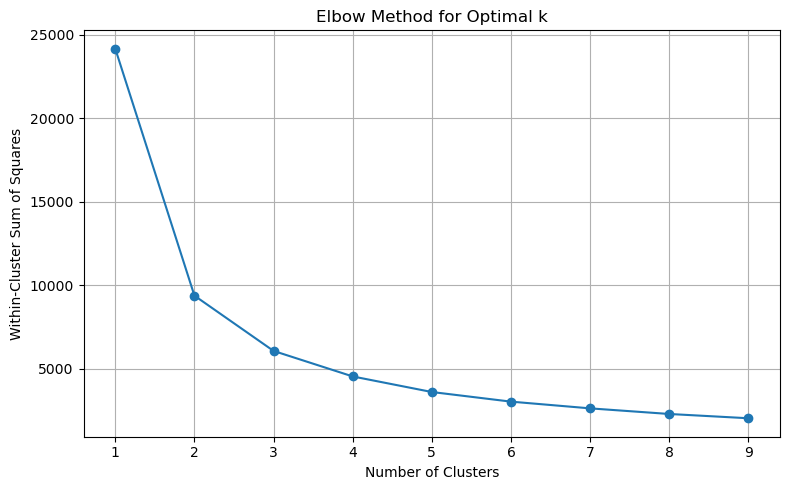

In [15]:
# Plot elbow curve 
plt.figure(figsize=(8, 5))
plt.plot(range(1,10), inertias, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Fit KMeans 
km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = km.fit_predict(X_scaled)

#Assign cluster labels back to ed (not diag_features)
ed["Cluster"] = labels

#Order clusters by average station burden
order = (ed.groupby("Cluster")["Visits_Per_Station"].mean().sort_values().index)
remap = {old: new for new, old in enumerate(order)}
ed["Cluster"] = ed["Cluster"].map(remap)

print("Clustering complete. Distribution of hospital-diagnosis-year rows per cluster:")
print(ed["Cluster"].value_counts().sort_index())


Clustering complete. Distribution of hospital-diagnosis-year rows per cluster:
Cluster
0    9229
1    2222
2     625
Name: count, dtype: int64


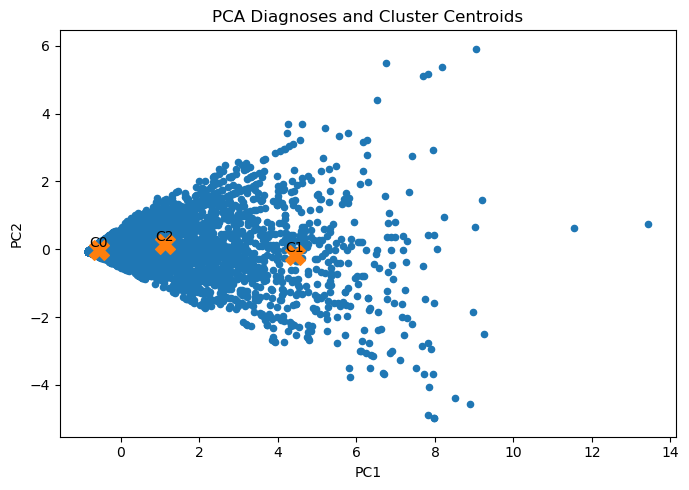

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(km.cluster_centers_)

# Plot categories and cluster centroids
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=20, marker='o')       
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, marker='X')  

# Label centroids
for i, (x, y) in enumerate(centroids_pca):
    plt.text(x, y, f"C{i}", fontsize=10, ha='center', va='bottom')

plt.title("PCA Diagnoses and Cluster Centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()



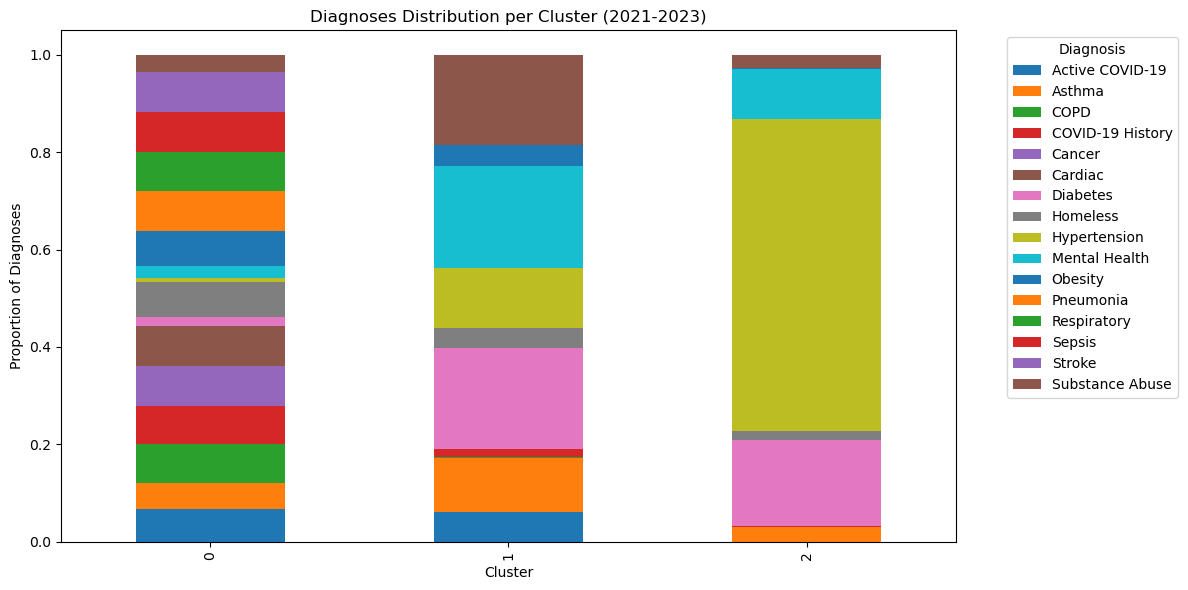

In [18]:
import matplotlib.pyplot as plt

# Count diagnoses per cluster
diag_counts = ed.groupby(["Cluster", "Category"]).size().unstack(fill_value=0)
# Show as proportion of cluster count
diag_perc = diag_counts.div(diag_counts.sum(axis=1), axis=0)


# Plot proportion
diag_perc.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Diagnoses Distribution per Cluster (2021-2023)")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Diagnoses")
plt.legend(title="Diagnosis", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
